Mediana dos custos: 9382.03
Número de linhas e colunas da base de treino: (1070, 7)
Número de linhas e colunas da base de teste: (268, 7)
Melhores hiperparâmetros encontrados: {'max_depth': 7, 'min_samples_split': 25}
Acuracia 0.9299065420560748
MCC:
 0.8662301137279158
Relatório de classificação:
               precision    recall  f1-score   support

           0       0.88      0.99      0.93       535
           1       0.99      0.87      0.93       535

    accuracy                           0.93      1070
   macro avg       0.94      0.93      0.93      1070
weighted avg       0.94      0.93      0.93      1070



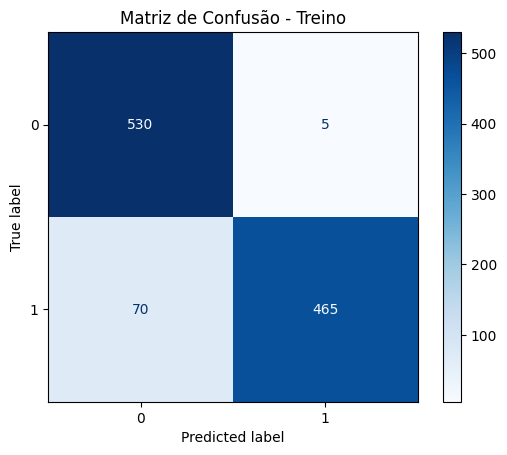

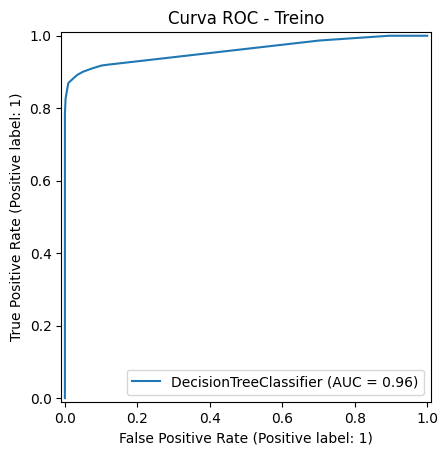

In [ ]:
import pandas as pd  # manipulação de tabelas (DataFrames)
from sklearn.model_selection import train_test_split, GridSearchCV  # divisão treino/teste e busca de hiperparâmetros
from sklearn.preprocessing import OneHotEncoder, StandardScaler  # codificação categórica e padronização numérica
from sklearn.impute import SimpleImputer  # preenchimento de valores faltantes
from sklearn.compose import ColumnTransformer  # aplica transformações diferentes em colunas
from sklearn.pipeline import Pipeline  # encadear pré-processamento e modelo
from sklearn.linear_model import LogisticRegression  # modelo de classificação binária
from sklearn.svm import SVC  # modelo de classificação SVM
from sklearn.tree import DecisionTreeClassifier  # classificador categórico de Decision Tree
from sklearn.neighbors import KNeighborsClassifier  # classificador categórico de KNN
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, matthews_corrcoef  # métricas de avaliação do modelo

import numpy as np  # operações numéricas e matrizes
import matplotlib.pyplot as plt  # criação de gráficos
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay  # visualizar curva ROC e matriz de confusão

# Carregando dataset
df = pd.read_csv('dados_aula_01_exemplo_01.csv')  # lê o arquivo aula_01_exemplo_01.csv em um DataFrame

# Feature engineering
df['tem_filhos'] = (df['children'] > 0).astype(int)
# cria uma nova coluna "tem_filhos" que indica se a pessoa tem filhos (1) ou não (0)
# (df['children'] > 0) cria uma série booleana (True/False)
# .astype(int) converte True para 1 e False para 0

mediana_charges = df["charges"].median()  # calcula a mediana da coluna "charges"

print(f"Mediana dos custos: {mediana_charges:.2f}")  # exibe a mediana dos custos formatada com 2 casas decimais

df["custos_categoricos"] = (df["charges"] >= mediana_charges).astype(int)  # cria uma nova coluna "custos_categoricos" que indica se o custo é alto (1) ou não (0)   
df[["charges", "custos_categoricos"]].head()  # exibe as primeiras linhas das colunas "charges" e "custos_categoricos"  

df["custos_categoricos"].value_counts()  # conta a frequência de cada categoria (0 e 1) na coluna "custos_categoricos"

x = df.drop(columns=["charges", "custos_categoricos"]) 
y = df["custos_categoricos"]

x.head()
 # define as features (X) removendo as colunas "charges" e "custos_categoricos"

 # Definição explícita das colunas por tipo
variaveis_categoricas = ['sex', 'smoker', 'region']
# lista com nomes das colunas categóricas (deve bater exatamente com os nomes do DataFrame)

variaveis_numericas = ['age', 'bmi', 'children', 'tem_filhos']
# lista das colunas numéricas que serão escalonadas

# divisão treino/teste

X_treino, X_teste, y_treino, y_teste = train_test_split(
    x,                  # covariáveis
    y,                  # variável target
    stratify=y,        
    test_size=0.2,      # 20% para teste
    random_state=42     # reprodutibilidade, como essa função aleatoriza os dados, vamos fixar essa aleatorização
)

print("Número de linhas e colunas da base de treino:", X_treino.shape)
print("Número de linhas e colunas da base de teste:", X_teste.shape)

# Pré-processamento

escalonador = StandardScaler()  # Escalonador, ele vai padronizar as variáveis numéricas

categorizador = OneHotEncoder(
    drop='first',               # O categorizador vai remover a primeiro dummy para evitar redundância
    handle_unknown='ignore'     # Ignora categorias desconhecidas em dado de teste
)

imputador_numerico = SimpleImputer(strategy='median')  
# imputador numérico usando mediana

imputador_categorico = SimpleImputer(strategy='most_frequent')  
# imputador categórico usando o moda

# Etapas de transformação das variáveis numéricas
etapas_numericas = Pipeline(
    [
        ("imputer", imputador_numerico),  # "imputer" é o nome da etapa - aplica a imputação (substitui valores ausentes pela mediana)
        ("scaler", escalonador)           # "scaler" é o nome da etapa - aplica padronização
    ]
)

etapas_numericas

# Etapas de transformação das variáveis numéricas
etapas_categoricas = Pipeline(
    [
        ("imputer", imputador_categorico),  # "imputer" é o nome da etapa - aplica a imputação (substitui valores ausentes pela moda)
        ("encoder", categorizador)           # "encoder" é o nome da etapa - aplica codificação one-hot 
    ]
)

etapas_categoricas

preprocessador = ColumnTransformer(
    transformers=[
        ("num", etapas_numericas, variaveis_numericas),  # Aplica as etapas numéricas às colunas listadas em variaveis_numericas
        ("cat", etapas_categoricas, variaveis_categoricas)  # Aplica as etapas categóricas às colunas listadas em variaveis_categoricas
    ]
)

x_treino_transformado = preprocessador.fit_transform(X_treino)  # Ajusta o preprocessador aos dados de treino e transforma os dados de treino   
x_teste_transformado = preprocessador.transform(X_teste)  # Transforma os dados de teste usando o preprocessador ajustado aos dados de treino

modelo = DecisionTreeClassifier(random_state=42)  # Cria um modelo de árvore de decisão com uma semente fixa para reprodutibilidade
param_grid = {
    'max_depth': [2, 3, 5, 7],  # Profundidade máxima da árvore (3, 5, 7 ou sem limite)
    'min_samples_split': [2, 5, 10, 15, 20, 25],  # Número mínimo de amostras para dividir um nó (2, 5 ou 10)
}

grid_search = GridSearchCV(
    estimator=modelo,  # O modelo a ser otimizado
    param_grid=param_grid,  # O grid de hiperparâmetros a ser testado
    cv=5,  # Número de folds para validação cruzada
    scoring='f1',  # Métrica de avaliação para escolher o melhor modelo 
)

grid_search.fit(x_treino_transformado, y_treino)  # Executa a busca em grade para encontrar os melhores hiperparâmetros usando os dados de treino
melhor_modelo = grid_search.best_estimator_  # Obtém o melhor modelo encontrado pela busca em grade
print("Melhores hiperparâmetros encontrados:", grid_search.best_params_)  # Exibe

y_pred_treino_arvore = melhor_modelo.predict(x_treino_transformado)  # Faz previsões usando o melhor modelo encontrado pela busca em grade

print("Acuracia", accuracy_score(y_treino, y_pred_treino_arvore))  # Calcula e exibe a acurácia das previsões no conjunto de treino
print("MCC:\n", matthews_corrcoef(y_treino, y_pred_treino_arvore))  # Calcula e exibe o coeficiente de correlação de Matthews das previsões no conjunto de treino
print("Relatório de classificação:\n", classification_report(y_treino, y_pred_treino_arvore))  # Calcula e exibe o relatório de


ConfusionMatrixDisplay.from_estimator(melhor_modelo, x_treino_transformado, y_treino, display_labels=['0', '1'], cmap=plt.cm.Blues, normalize=None)  # Exibe a matriz de confusão para o conjunto de treino
plt.title("Matriz de Confusão - Treino")  # Define o título do gráfico
plt.show()  # Exibe o gráfico   

RocCurveDisplay.from_estimator(melhor_modelo, x_treino_transformado, y_treino)  # Exibe a curva ROC para o conjunto de treino
plt.title("Curva ROC - Treino")  # Define o título do gráfico
plt.show()  # Exibe o gráfico


modelo_svc = SVC(probability=True, random_state=42)  # Cria um modelo de Support Vector Machine com probabilidade habilitada e uma semente fixa para reprodutibilidade
param_grid_svc = {
    'C': [0.1, 1, 10],  # Parâmetro de regularização (0.1, 1 ou 10)
    'kernel': ['linear', 'rbf'],  # Tipo de kernel (linear ou RBF)
  "gama": ['scale', 'auto']  # Parâmetro de kernel para o kernel RBF (scale ou auto)
}